In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving Online_Retail_Cleaned_Task2.xlsx to Online_Retail_Cleaned_Task2.xlsx


In [ ]:
df = pd.read_excel("Online_Retail_Cleaned_Task2.xlsx")

In [24]:
df.shape

(524878, 9)

In [25]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,S
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [26]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object')

In [27]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,int64
Country,object
TotalAmount,object


In [28]:
pd.to_numeric(df["TotalAmount"], errors="coerce").isna().sum()

np.int64(1)

In [29]:
df[df["TotalAmount"].apply(lambda x: pd.to_numeric(x, errors="coerce")).isna()][["InvoiceNo", "Description", "Quantity", "UnitPrice", "TotalAmount"]]

,InvoiceNo,Description,Quantity,UnitPrice,TotalAmount
0,536365,White Hanging Heart T-Light Holder,6,2.55,S


In [30]:
df["TotalAmount"] = pd.to_numeric(df["TotalAmount"], errors="coerce")
df["TotalAmount"] = df["TotalAmount"].fillna(df["Quantity"] * df["UnitPrice"])

In [31]:
df[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [33]:
df["TotalAmount"].dtype

dtype('float64')

In [34]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalAmount,0


In [35]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,524878.000000,524878,524878.000000,524878.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,11437.732164,20.275399
min,1.000000,2010-12-01 08:26:00,0.001000,0.000000,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000,0.000000,3.900000
50%,4.000000,2011-07-20 11:22:00,2.080000,14350.000000,9.920000
75%,11.000000,2011-10-19 11:41:00,4.130000,16245.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,156.280031,NaN,36.093028,6799.513627,271.693566


In [36]:
total_revenue = df["TotalAmount"].sum()
total_revenue

np.float64(10642110.803999998)

In [37]:
total_quantity = df["Quantity"].sum()
total_quantity

np.int64(5572420)

In [38]:
total_transactions = df["InvoiceNo"].nunique()
total_transactions

19960

In [39]:
total_customers = df["CustomerID"].nunique()
total_customers

4339

In [40]:
country_revenue = (
    df.groupby("Country")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_revenue

,TotalAmount
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


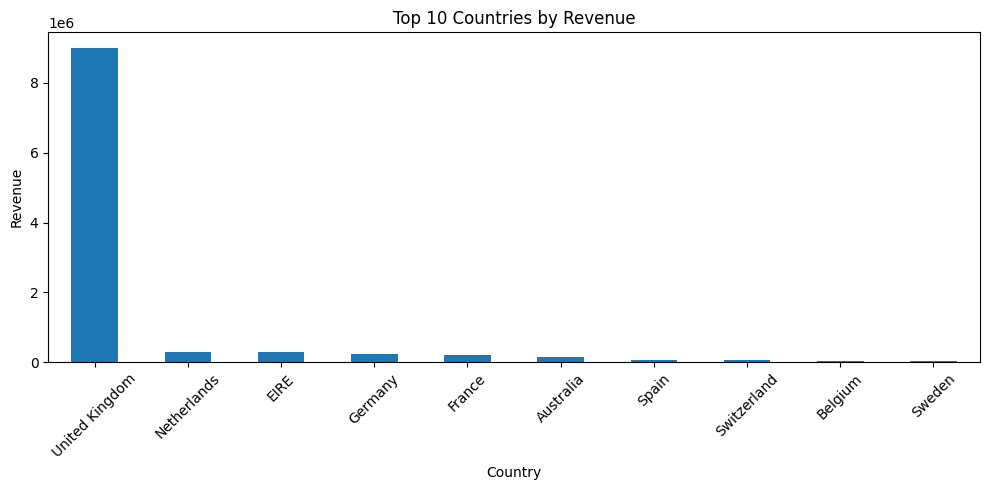

In [41]:
country_revenue.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
product_revenue = (
    df.groupby("Description")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

product_revenue

,TotalAmount
Description,
Dotcom Postage,206248.77
Regency Cakestand 3 Tier,174156.54
"Paper Craft , Little Birdie",168469.60
White Hanging Heart T-Light Holder,106236.72
Party Bunting,99445.23
Jumbo Bag Red Retrospot,94159.81
Medium Ceramic Top Storage Jar,81700.92
Postage,78101.88
Manual,77752.82


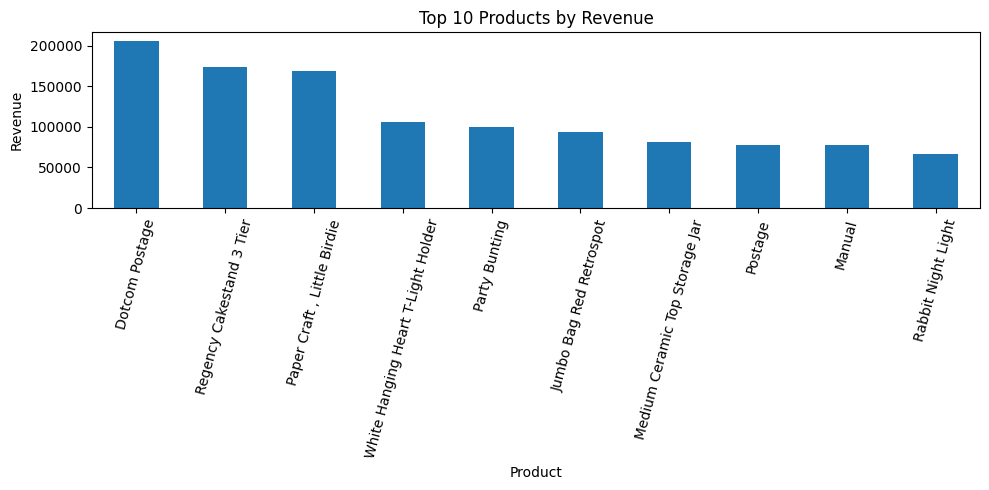

In [43]:
product_revenue.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [44]:
product_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

product_quantity

,Quantity
Description,
"Paper Craft , Little Birdie",80995
Medium Ceramic Top Storage Jar,78033
World War 2 Gliders Asstd Designs,54951
Jumbo Bag Red Retrospot,48371
White Hanging Heart T-Light Holder,37872
Popcorn Holder,36749
Pack Of 72 Retrospot Cake Cases,36396
Assorted Colour Bird Ornament,36362
Rabbit Night Light,30739


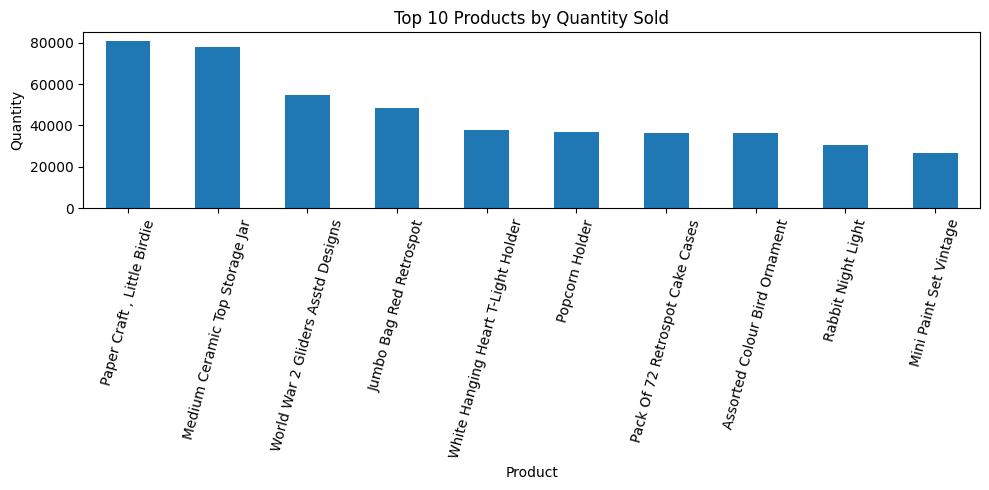

In [45]:
product_quantity.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [46]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

df[["InvoiceDate", "Month"]].head()

,InvoiceDate,Month
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [47]:
monthly_revenue = (
    df.groupby("Month")["TotalAmount"]
      .sum()
)

monthly_revenue

,TotalAmount
Month,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


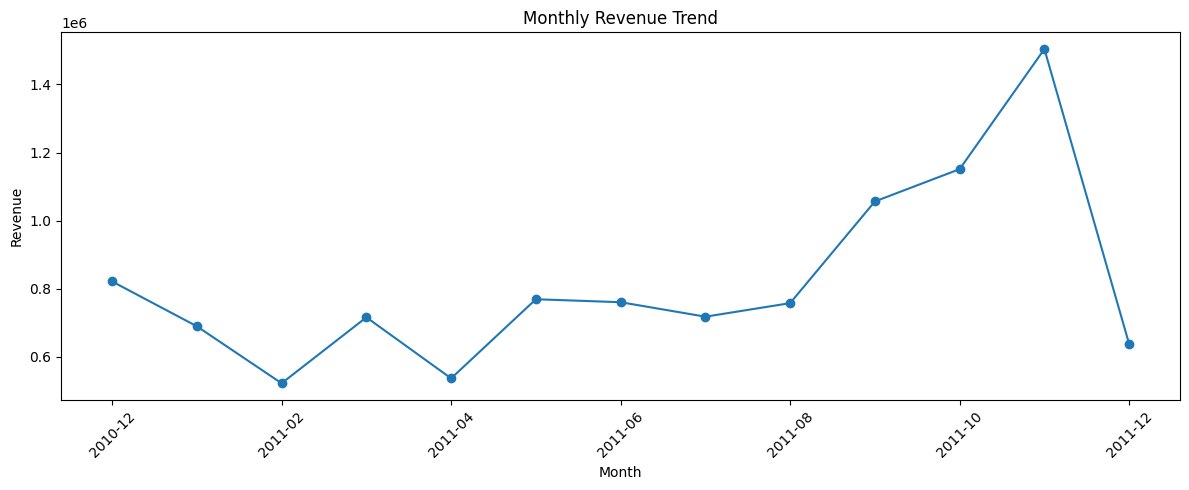

In [48]:
monthly_revenue.plot(kind="line", figsize=(12,5), marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
monthly_quantity = (
    df.groupby("Month")["Quantity"]
      .sum()
)

monthly_quantity

,Quantity
Month,
2010-12,358019
2011-01,387099
2011-02,282934
2011-03,376599
2011-04,307953
2011-05,395001
2011-06,388511
2011-07,399693
2011-08,421020


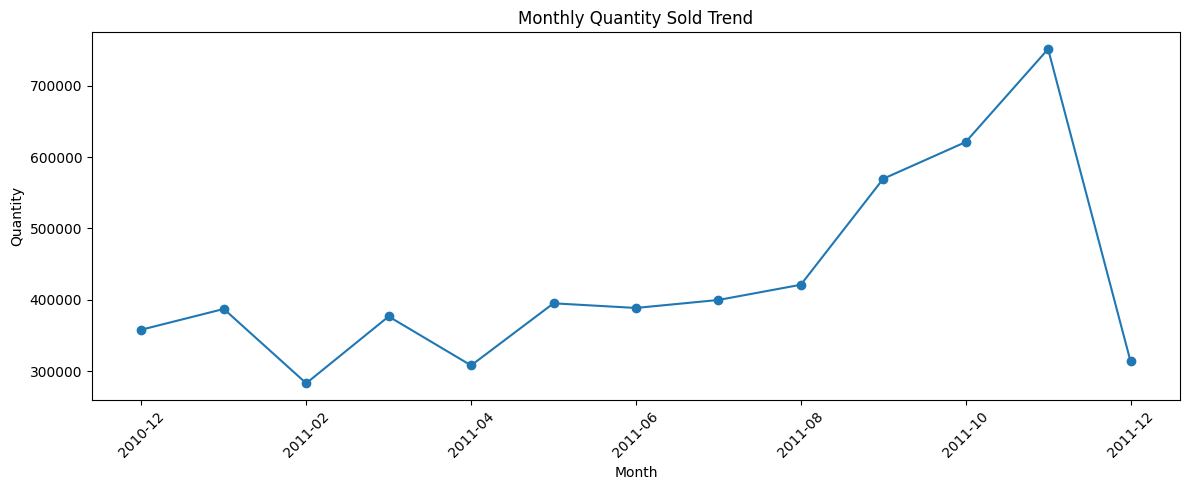

In [50]:
monthly_quantity.plot(kind="line", figsize=(12,5), marker="o")
plt.title("Monthly Quantity Sold Trend")
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
average_order_value = total_revenue / total_transactions
average_order_value

np.float64(533.1718839679357)

In [52]:
identified_customers = df[df["CustomerID"] != 0]["CustomerID"].nunique()
unidentified_customers = (df["CustomerID"] == 0).sum()

identified_customers, unidentified_customers

(4338, np.int64(132186))

In [53]:
unidentified_percentage = (unidentified_customers / len(df)) * 100
unidentified_percentage

np.float64(25.184138028265618)

In [54]:
df.loc[df["Quantity"].idxmax()]

,523404
InvoiceNo,581483
StockCode,23843
Description,"Paper Craft , Little Birdie"
Quantity,80995
InvoiceDate,2011-12-09 09:15:00
UnitPrice,2.08
CustomerID,16446
Country,United Kingdom
TotalAmount,168469.6
Month,2011-12


In [55]:
outlier_revenue_share = (168469.60 / total_revenue) * 100
outlier_revenue_share

np.float64(1.5830468513509384)

In [56]:
uk_revenue_share = (country_revenue["United Kingdom"] / total_revenue) * 100
uk_revenue_share

np.float64(84.58607751590557)

In [57]:
highest_revenue_month = monthly_revenue.idxmax()
highest_revenue_value = monthly_revenue.max()

highest_revenue_month, highest_revenue_value

('2011-11', 1503866.78)

In [58]:
lowest_revenue_month = monthly_revenue.idxmin()
lowest_revenue_value = monthly_revenue.min()

lowest_revenue_month, lowest_revenue_value

('2011-02', 522545.56)

In [59]:
revenue_difference = highest_revenue_value - lowest_revenue_value
revenue_ratio = highest_revenue_value / lowest_revenue_value

revenue_difference, revenue_ratio

(981321.22, 2.877962985658131)

In [60]:
top10_product_revenue = product_revenue.sum()
top10_product_revenue_share = (top10_product_revenue / total_revenue) * 100

top10_product_revenue, top10_product_revenue_share

(np.float64(1153142.32), np.float64(10.835654140779798))

In [61]:
summary = {
    "Total Revenue": total_revenue,
    "Total Quantity Sold": df["Quantity"].sum(),
    "Total Invoices": df["InvoiceNo"].nunique(),
    "Average Order Value": average_order_value,
    "Identified Customers": identified_customers,
    "Unidentified Customer Records": unidentified_customers,
    "Unidentified Customer Records %": unidentified_percentage,
    "UK Revenue Share %": uk_revenue_share,
    "Top 10 Description Revenue": top10_product_revenue,
    "Top 10 Description Revenue Share %": top10_product_revenue_share,
    "Highest Revenue Month": highest_revenue_month,
    "Highest Revenue Month Value": highest_revenue_value,
    "Lowest Revenue Month": lowest_revenue_month,
    "Lowest Revenue Month Value": lowest_revenue_value
}

summary

{'Total Revenue': np.float64(10642110.803999998),
 'Total Quantity Sold': np.int64(5572420),
 'Total Invoices': 19960,
 'Average Order Value': np.float64(533.1718839679357),
 'Identified Customers': 4338,
 'Unidentified Customer Records': np.int64(132186),
 'Unidentified Customer Records %': np.float64(25.184138028265618),
 'UK Revenue Share %': np.float64(84.58607751590557),
 'Top 10 Description Revenue': np.float64(1153142.32),
 'Top 10 Description Revenue Share %': np.float64(10.835654140779798),
 'Highest Revenue Month': '2011-11',
 'Highest Revenue Month Value': 1503866.78,
 'Lowest Revenue Month': '2011-02',
 'Lowest Revenue Month Value': 522545.56}

In [62]:
country_quantity = (
    df.groupby("Country")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_quantity

,Quantity
Country,
United Kingdom,4646906
Netherlands,200361
EIRE,147007
Germany,119154
France,112060
Australia,83891
Sweden,36078
Switzerland,30617
Spain,27933


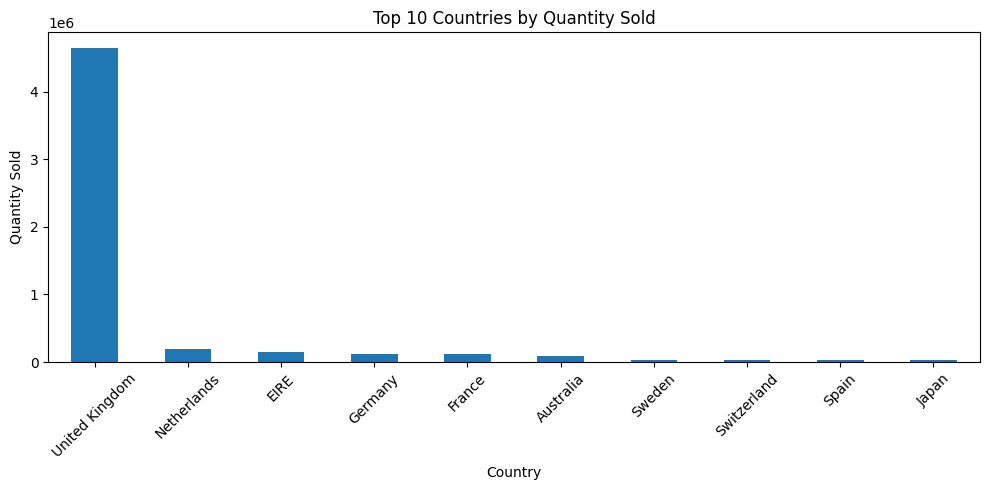

In [63]:
country_quantity.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries by Quantity Sold")
plt.xlabel("Country")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
monthly_summary = pd.DataFrame({
    "Revenue": monthly_revenue,
    "Quantity": monthly_quantity
})

monthly_summary

,Revenue,Quantity
Month,,
2010-12,821452.730,358019
2011-01,689811.610,387099
2011-02,522545.560,282934
2011-03,716215.260,376599
2011-04,536968.491,307953
2011-05,769296.610,395001
2011-06,760547.010,388511
2011-07,718076.121,399693
2011-08,757841.380,421020


In [65]:
monthly_growth = monthly_revenue.pct_change() * 100

monthly_growth

,TotalAmount
Month,
2010-12,NaN
2011-01,-16.025404
2011-02,-24.248077
2011-03,37.062740
2011-04,-25.026941
2011-05,43.266620
2011-06,-1.137351
2011-07,-5.584256
2011-08,5.537750


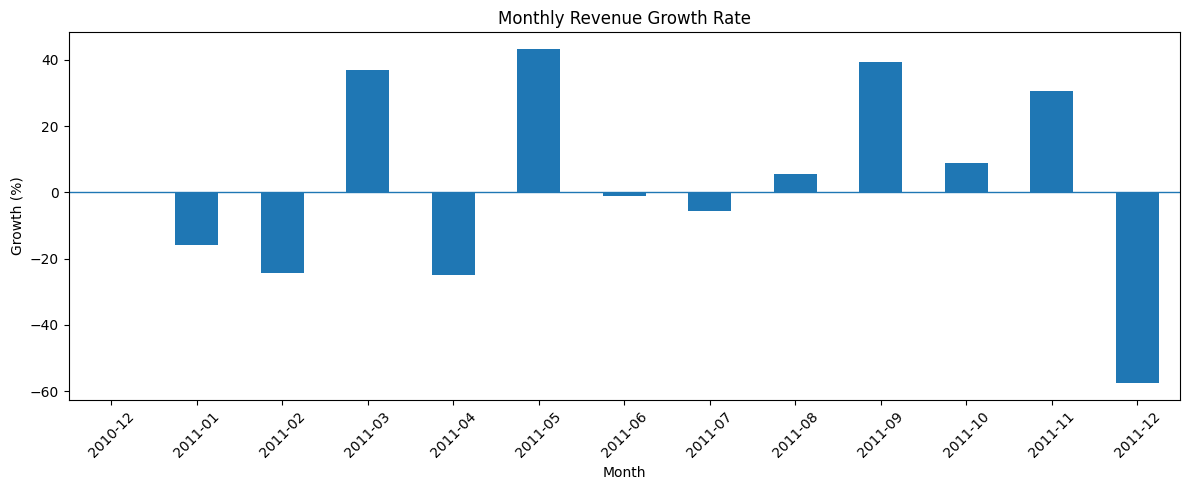

In [66]:
monthly_growth.plot(kind="bar", figsize=(12,5))

plt.title("Monthly Revenue Growth Rate")
plt.xlabel("Month")
plt.ylabel("Growth (%)")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [67]:
highest_quantity_record = df.loc[df["Quantity"].idxmax()]

highest_quantity_record

,523404
InvoiceNo,581483
StockCode,23843
Description,"Paper Craft , Little Birdie"
Quantity,80995
InvoiceDate,2011-12-09 09:15:00
UnitPrice,2.08
CustomerID,16446
Country,United Kingdom
TotalAmount,168469.6
Month,2011-12


In [68]:
top10_product_revenue_df = product_revenue.reset_index()

top10_product_revenue_df.columns = ["Description", "Revenue"]

top10_product_revenue_df

,Description,Revenue
0,Dotcom Postage,206248.77
1,Regency Cakestand 3 Tier,174156.54
2,"Paper Craft , Little Birdie",168469.60
3,White Hanging Heart T-Light Holder,106236.72
4,Party Bunting,99445.23
5,Jumbo Bag Red Retrospot,94159.81
6,Medium Ceramic Top Storage Jar,81700.92
7,Postage,78101.88
8,Manual,77752.82
9,Rabbit Night Light,66870.03


In [69]:
top10_product_quantity_df = product_quantity.reset_index()

top10_product_quantity_df.columns = ["Description", "Quantity"]

top10_product_quantity_df

,Description,Quantity
0,"Paper Craft , Little Birdie",80995
1,Medium Ceramic Top Storage Jar,78033
2,World War 2 Gliders Asstd Designs,54951
3,Jumbo Bag Red Retrospot,48371
4,White Hanging Heart T-Light Holder,37872
5,Popcorn Holder,36749
6,Pack Of 72 Retrospot Cake Cases,36396
7,Assorted Colour Bird Ornament,36362
8,Rabbit Night Light,30739
9,Mini Paint Set Vintage,26633


In [70]:
print("===== SWYNEX TASK 2 — KEY KPIs =====")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Quantity Sold: {df['Quantity'].sum():,}")
print(f"Total Invoices: {df['InvoiceNo'].nunique():,}")
print(f"Average Order Value: £{average_order_value:,.2f}")
print(f"Identified Customers: {identified_customers:,}")
print(f"Unidentified Customer Records: {unidentified_customers:,}")
print(f"Unidentified Customer Records: {unidentified_percentage:.2f}%")
print(f"UK Revenue Share: {uk_revenue_share:.2f}%")
print(f"Top 10 Description Revenue Share: {top10_product_revenue_share:.2f}%")
print(f"Highest Revenue Month: {highest_revenue_month}")
print(f"Highest Revenue Month Revenue: £{highest_revenue_value:,.2f}")
print(f"Lowest Revenue Month: {lowest_revenue_month}")
print(f"Lowest Revenue Month Revenue: £{lowest_revenue_value:,.2f}")

===== SWYNEX TASK 2 — KEY KPIs =====
Total Revenue: £10,642,110.80
Total Quantity Sold: 5,572,420
Total Invoices: 19,960
Average Order Value: £533.17
Identified Customers: 4,338
Unidentified Customer Records: 132,186
Unidentified Customer Records: 25.18%
UK Revenue Share: 84.59%
Top 10 Description Revenue Share: 10.84%
Highest Revenue Month: 2011-11
Highest Revenue Month Revenue: £1,503,866.78
Lowest Revenue Month: 2011-02
Lowest Revenue Month Revenue: £522,545.56


Key Insights

1. UK Revenue Concentration

The United Kingdom generated approximately £9.00 million, accounting for 84.59% of total revenue. This indicates that the dataset's revenue is heavily concentrated in the UK market.

2. Monthly Revenue Variation

November 2011 recorded the highest monthly revenue at £1,503,866.78, while February 2011 recorded the lowest at £522,545.56. November revenue was approximately 2.88 times February revenue.

3. High-Volume Product Description

Paper Craft, Little Birdie recorded 80,995 units sold and generated £168,469.60 in revenue. It ranked first among the analyzed descriptions by quantity sold.

4. Customer Identification Limitation

132,186 records, representing 25.18% of the cleaned dataset, have CustomerID = 0. Therefore, customer-level analysis should be interpreted carefully because a significant portion of records does not have an identified customer.

5. Revenue Distribution

The top 10 descriptions generated £1,153,142.32, representing 10.84% of total revenue. This indicates that revenue is distributed across a broad range of descriptions rather than being dominated by the top 10 alone.

6. Potential High-Volume Outlier

A record for Paper Craft, Little Birdie contains 80,995 units and generates £168,469.60, approximately 1.58% of total revenue. Since the record contains populated customer, date, quantity and price fields, it should be treated as a potential outlier requiring validation rather than automatically classified as an error.

7. Monthly Revenue and Quantity Trend

Monthly revenue and quantity generally increase toward November, with November recording approximately 751,377 units and £1.50 million in revenue. December should not be interpreted as a normal full-month decline because the dataset ends on 9 December 2011.

8. Overall Dataset Scale

The cleaned dataset contains 19,960 invoices, 5,572,420 units sold, and approximately £10.64 million in total revenue.bold text italicized text